# <font color='green'>Data Visualisation Midterm CW / What factors explain success in FIFA World Cups?
</font> 

## <font color='green'>Research Questions</font> 

1. To what extent is GDP per capita associated with a country's FIFA World Cup performance?  
2. Does hosting the FIFA World Cup provide a measurable competitive advantage?  
3. Which contributes more to World Cup success: attacking efficiency or defensive strength?  

## <font color='green'>1 Datasets manipulation 15%</font> 
### <font color='green'>1.1 Datasets</font> 
**DATASET 1** All international futbol matches:https://github.com/martj42/international_results

**DATASET 2** GDP-PIB per Capita: https://www.kaggle.com/datasets/fredericksalazar/global-gdp-pib-per-capita-dataset-1960-present

### <font color='green'>1.2 Data Preproccesing</font> 

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

# Visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Load World Cup matches dataset
wc_matches = pd.read_csv("results.csv")

# Load GDP per capita dataset
gdp = pd.read_csv("pib_per_capita_countries_dataset.csv")

In [3]:
print(wc_matches.head())

print(gdp.head())

         date home_team away_team  home_score  away_score tournament     city  \
0  1872-11-30  Scotland   England         0.0         0.0   Friendly  Glasgow   
1  1873-03-08   England  Scotland         4.0         2.0   Friendly   London   
2  1874-03-07  Scotland   England         2.0         1.0   Friendly  Glasgow   
3  1875-03-06   England  Scotland         2.0         2.0   Friendly   London   
4  1876-03-04  Scotland   England         3.0         0.0   Friendly  Glasgow   

    country  neutral  
0  Scotland    False  
1   England    False  
2  Scotland    False  
3   England    False  
4  Scotland    False  
  country_code country_name           region     sub_region  \
0          AFG   AFGANISTAN  ASIA MERIDIONAL  SOUTHERN ASIA   
1          AFG   AFGANISTAN  ASIA MERIDIONAL  SOUTHERN ASIA   
2          AFG   AFGANISTAN  ASIA MERIDIONAL  SOUTHERN ASIA   
3          AFG   AFGANISTAN  ASIA MERIDIONAL  SOUTHERN ASIA   
4          AFG   AFGANISTAN  ASIA MERIDIONAL  SOUTHERN ASIA 

In [4]:
#Checking structure and datatypes of the datasets
print("World Cup Dataset")
wc_matches.info()

print("\nGDP Dataset")
gdp.info()

World Cup Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49505 entries, 0 to 49504
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49505 non-null  object 
 1   home_team   49505 non-null  object 
 2   away_team   49505 non-null  object 
 3   home_score  49502 non-null  float64
 4   away_score  49502 non-null  float64
 5   tournament  49505 non-null  object 
 6   city        49505 non-null  object 
 7   country     49505 non-null  object 
 8   neutral     49505 non-null  bool   
dtypes: bool(1), float64(2), object(6)
memory usage: 3.1+ MB

GDP Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13760 entries, 0 to 13759
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   country_code         13760 non-null  object 
 1   country_name         13760 non-null  object 
 2   region               8320 non-null 

In [5]:
print("Missing values - World Cup Dataset")
display(wc_matches.isnull().sum().sort_values(ascending=False))

print("\nMissing values - GDP Dataset")
display(gdp.isnull().sum().sort_values(ascending=False))

Missing values - World Cup Dataset


away_score    3
home_score    3
date          0
away_team     0
home_team     0
tournament    0
city          0
country       0
neutral       0
dtype: int64


Missing values - GDP Dataset


intermediate_region    8000
region                 5440
gdp_variation           215
country_code              0
country_name              0
sub_region                0
indicator_code            0
indicator_name            0
year                      0
gdp_per_capita            0
dtype: int64

In [6]:
#Summary statistics of first dataset
wc_matches.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,49505,16484,2012-02-29,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN
home_team,49505,327,Brazil,618,NaN,NaN,NaN,NaN,NaN,NaN,NaN
away_team,49505,321,Uruguay,585,NaN,NaN,NaN,NaN,NaN,NaN,NaN
home_score,49502.0,NaN,NaN,NaN,1.757202,1.773803,0.0,1.0,1.0,2.0,31.0
away_score,49502.0,NaN,NaN,NaN,1.181912,1.401651,0.0,0.0,1.0,2.0,21.0
tournament,49505,200,Friendly,18388,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,49505,2089,Kuala Lumpur,745,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,49505,269,United States,1581,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neutral,49505,2,False,36360,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
#Summary statistics of fsecond dataset
gdp.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
country_code,13760,215,AFG,64,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country_name,13760,215,AFGANISTAN,64,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,8320,6,ÁFRICA AL SUR DEL SAHARA (EXCLUIDO ALTOS INGRE...,3008,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sub_region,13760,17,SUB-SAHARAN AFRICA,3072,NaN,NaN,NaN,NaN,NaN,NaN,NaN
intermediate_region,5760,7,CARIBBEAN,1408,NaN,NaN,NaN,NaN,NaN,NaN,NaN
indicator_code,13760,1,NY.GDP.PCAP.CD,13760,NaN,NaN,NaN,NaN,NaN,NaN,NaN
indicator_name,13760,1,PIB PER CAPITA (US$ A PRECIOS ACTUALES),13760,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,13760.0,NaN,NaN,NaN,1991.5,18.473624,1960.0,1975.75,1991.5,2007.25,2023.0
gdp_per_capita,13760.0,NaN,NaN,NaN,7654.829033,17076.866349,0.0,225.615482,1210.690043,6331.442354,256580.515123
gdp_variation,13545.0,NaN,NaN,NaN,7256.965822,844412.457334,-64.423582,0.0,0.943213,3.816873,98275246.767504


We will create a new column with y year that will help to merge with the year of the other dataset, also leave just the world cup matches of the table

In [8]:
# Convert date to datetime
wc_matches['date'] = pd.to_datetime(wc_matches['date'])

# Create a new integer year column
wc_matches['year'] = wc_matches['date'].dt.year.astype('int64')
print(wc_matches.head())

        date home_team away_team  home_score  away_score tournament     city  \
0 1872-11-30  Scotland   England         0.0         0.0   Friendly  Glasgow   
1 1873-03-08   England  Scotland         4.0         2.0   Friendly   London   
2 1874-03-07  Scotland   England         2.0         1.0   Friendly  Glasgow   
3 1875-03-06   England  Scotland         2.0         2.0   Friendly   London   
4 1876-03-04  Scotland   England         3.0         0.0   Friendly  Glasgow   

    country  neutral  year  
0  Scotland    False  1872  
1   England    False  1873  
2  Scotland    False  1874  
3   England    False  1875  
4  Scotland    False  1876  


In [9]:
wc_matches = wc_matches[wc_matches['tournament'] == 'FIFA World Cup'].copy()
print(wc_matches.head())
print("Dataset shape:", wc_matches.shape)

           date  home_team      away_team  home_score  away_score  \
1490 1930-07-13    Belgium  United States         0.0         3.0   
1491 1930-07-13     France         Mexico         4.0         1.0   
1492 1930-07-14     Brazil     Yugoslavia         1.0         2.0   
1493 1930-07-14       Peru        Romania         1.0         3.0   
1494 1930-07-15  Argentina         France         1.0         0.0   

          tournament        city  country  neutral  year  
1490  FIFA World Cup  Montevideo  Uruguay     True  1930  
1491  FIFA World Cup  Montevideo  Uruguay     True  1930  
1492  FIFA World Cup  Montevideo  Uruguay     True  1930  
1493  FIFA World Cup  Montevideo  Uruguay     True  1930  
1494  FIFA World Cup  Montevideo  Uruguay     True  1930  
Dataset shape: (1064, 10)


In [10]:
# Display all years to check if we have all world cups
world_cup_years = sorted(wc_matches['year'].unique())
print(world_cup_years)

[np.int64(1930), np.int64(1934), np.int64(1938), np.int64(1950), np.int64(1954), np.int64(1958), np.int64(1962), np.int64(1966), np.int64(1970), np.int64(1974), np.int64(1978), np.int64(1982), np.int64(1986), np.int64(1990), np.int64(1994), np.int64(1998), np.int64(2002), np.int64(2006), np.int64(2010), np.int64(2014), np.int64(2018), np.int64(2022), np.int64(2026)]


In [11]:
# Combine home and away teams into a single list this will help us to merge with the gdp dataset later
all_teams = sorted(
    set(wc_matches['home_team']).union(set(wc_matches['away_team']))
)

print(f"Total unique teams: {len(all_teams)}")
print(all_teams)

Total unique teams: 86
['Algeria', 'Angola', 'Argentina', 'Australia', 'Austria', 'Belgium', 'Bolivia', 'Bosnia and Herzegovina', 'Brazil', 'Bulgaria', 'Cameroon', 'Canada', 'Cape Verde', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cuba', 'Curaçao', 'Czech Republic', 'Czechoslovakia', 'DR Congo', 'Denmark', 'Ecuador', 'Egypt', 'El Salvador', 'England', 'France', 'German DR', 'Germany', 'Ghana', 'Greece', 'Haiti', 'Honduras', 'Hungary', 'Iceland', 'Indonesia', 'Iran', 'Iraq', 'Israel', 'Italy', 'Ivory Coast', 'Jamaica', 'Japan', 'Jordan', 'Kuwait', 'Mexico', 'Morocco', 'Netherlands', 'New Zealand', 'Nigeria', 'North Korea', 'Northern Ireland', 'Norway', 'Panama', 'Paraguay', 'Peru', 'Poland', 'Portugal', 'Qatar', 'Republic of Ireland', 'Romania', 'Russia', 'Saudi Arabia', 'Scotland', 'Senegal', 'Serbia', 'Slovakia', 'Slovenia', 'South Africa', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'Togo', 'Trinidad and Tobago', 'Tunisia', 'Turkey', 'Ukraine', 'United Arab Emirates

For the GDP dataset we will: first drop unnecesary columns, then drop all rows where column gdp_per_capita is missing or 0 and finally check all posible values of column country_name

In [12]:
# Drop unnecessary columns
gdp = gdp.drop(columns=[
    'country_code',
    'region',
    'sub_region',
    'intermediate_region',
    'indicator_code',
    'indicator_name',
    'gdp_variation'
])

# Remove rows with missing or zero GDP per capita
gdp = gdp.dropna(subset=['gdp_per_capita'])
gdp = gdp[gdp['gdp_per_capita'] > 0].copy()

# Verify the dataset
print("Dataset shape:", gdp.shape)
gdp.head()

Dataset shape: (11320, 3)


,country_name,year,gdp_per_capita
40,AFGANISTAN,2000,174.930991
41,AFGANISTAN,2001,138.706822
42,AFGANISTAN,2002,178.954088
43,AFGANISTAN,2003,198.871116
44,AFGANISTAN,2004,221.763654


In [13]:
# Get all unique country names
countries = sorted(gdp['country_name'].unique())

print(f"Number of unique countries: {len(countries)}")
print(countries)

Number of unique countries: 212
['AFGANISTAN', 'ALBANIA', 'ALEMANIA', 'ANDORRA', 'ANGOLA', 'ANTIGUA Y BARBUDA', 'ARABIA SAUDITA', 'ARGELIA', 'ARGENTINA', 'ARMENIA', 'ARUBA', 'AUSTRALIA', 'AUSTRIA', 'AZERBAIYAN', 'BAHAMAS', 'BAHREIN', 'BANGLADESH', 'BARBADOS', 'BELARUS', 'BELGICA', 'BELICE', 'BENIN', 'BERMUDAS', 'BHUTAN', 'BOLIVIA', 'BOSNIA Y HERZEGOVINA', 'BOTSWANA', 'BRASIL', 'BRUNEI DARUSSALAM', 'BULGARIA', 'BURKINA FASO', 'BURUNDI', 'CABO VERDE', 'CAMBOYA', 'CAMERUN', 'CANADA', 'CHAD', 'CHILE', 'CHINA', 'CHIPRE', 'COLOMBIA', 'COMORAS', 'CONGO, REPUBLICA DEL', 'CONGO, REPUBLICA DEMOCRATICA DEL', 'COREA, REPUBLICA DE', 'COSTA RICA', "COTE D'IVOIRE", 'CROACIA', 'CUBA', 'CURACAO', 'DINAMARCA', 'DJIBOUTI', 'DOMINICA', 'ECUADOR', 'EGIPTO, REPUBLICA ARABE DE', 'EL SALVADOR', 'EMIRATOS ARABES UNIDOS', 'ERITREA', 'ESLOVENIA', 'ESPANA', 'ESTADOS UNIDOS', 'ESTONIA', 'ESWATINI', 'ETIOPIA', 'FEDERACION DE RUSIA', 'FIJI', 'FILIPINAS', 'FINLANDIA', 'FRANCIA', 'GABON', 'GAMBIA', 'GEORGIA', 'GHANA',

In [14]:
#Now we will create a country mapping auxiliary column to standardize the country names in both tables
country_mapping = {
    # Direct translations
    'ANGOLA': 'Angola',
    'ALEMANIA' : 'Germany',
    'ARGELIA': 'Algeria',
    'ARGENTINA': 'Argentina',
    'AUSTRALIA': 'Australia',
    'AUSTRIA': 'Austria',
    'BELGICA': 'Belgium',
    'BOLIVIA': 'Bolivia',
    'BRASIL': 'Brazil',
    'BULGARIA': 'Bulgaria',
    'CAMERUN': 'Cameroon',
    'CANADA': 'Canada',
    'CHILE': 'Chile',
    'CHINA': 'China',
    'COLOMBIA': 'Colombia',
    'COSTA RICA': 'Costa Rica',
    'CROACIA': 'Croatia',
    'CUBA': 'Cuba',
    'CURACAO': 'Curaçao',
    'DINAMARCA': 'Denmark',
    'ECUADOR': 'Ecuador',
    'EL SALVADOR': 'El Salvador',
    'ESLOVENIA': 'Slovenia',
    'ESPANA': 'Spain',
    'ESTADOS UNIDOS': 'United States',
    'FRANCIA': 'France',
    'GHANA': 'Ghana',
    'GRECIA': 'Greece',
    'HAITI': 'Haiti',
    'HONDURAS': 'Honduras',
    'HUNGRIA': 'Hungary',
    'INDONESIA': 'Indonesia',
    'IRAQ': 'Iraq',
    'IRLANDA': 'Republic of Ireland',
    'ISLANDIA': 'Iceland',
    'ISRAEL': 'Israel',
    'ITALIA': 'Italy',
    'JAMAICA': 'Jamaica',
    'JAPON': 'Japan',
    'JORDANIA': 'Jordan',
    'KUWAIT': 'Kuwait',
    'MARRUECOS': 'Morocco',
    'MEXICO': 'Mexico',
    'NIGERIA': 'Nigeria',
    'NORUEGA': 'Norway',
    'NUEVA ZELANDIA': 'New Zealand',
    'PAISES BAJOS': 'Netherlands',
    'PANAMA': 'Panama',
    'PARAGUAY': 'Paraguay',
    'PERU': 'Peru',
    'POLONIA': 'Poland',
    'PORTUGAL': 'Portugal',
    'QATAR': 'Qatar',
    'REPUBLICA ESLOVACA': 'Slovakia',
    'RUMANIA': 'Romania',
    'SENEGAL': 'Senegal',
    'SERBIA': 'Serbia',
    'SUDAFRICA': 'South Africa',
    'SUECIA': 'Sweden',
    'SUIZA': 'Switzerland',
    'TOGO': 'Togo',
    'TUNEZ': 'Tunisia',
    'TURQUIA': 'Turkey',
    'TRINIDAD Y TOBAGO': 'Trinidad and Tobago',
    'UCRANIA': 'Ukraine',
    'URUGUAY': 'Uruguay',
    'UZBEKISTAN': 'Uzbekistan',

    # Different names
    'ARABIA SAUDITA': 'Saudi Arabia',
    'BOSNIA Y HERZEGOVINA': 'Bosnia and Herzegovina',
    'CABO VERDE': 'Cape Verde',
    'CONGO, REPUBLICA DEMOCRATICA DEL': 'DR Congo',
    "COTE D'IVOIRE": 'Ivory Coast',
    'COREA, REPUBLICA DE': 'South Korea',
    'EGIPTO, REPUBLICA ARABE DE': 'Egypt',
    'EMIRATOS ARABES UNIDOS': 'United Arab Emirates',
    'FEDERACION DE RUSIA': 'Russia',
    'IRAN, REPUBLICA ISLAMICA DEL': 'Iran',
    'REPUBLICA CHECA': 'Czech Republic',
    'REINO UNIDO': 'England'
}

gdp['country_std'] = (gdp['country_name'].replace(country_mapping))

wc_matches['home_team_std'] = wc_matches['home_team']
wc_matches['away_team_std'] = wc_matches['away_team']

Now we will merge the 2 datasets using the year and country names as keys

In [15]:
# Left join: World Cup matches + GDP of the home team
wc_matches = wc_matches.merge(
    gdp[['country_std', 'year', 'gdp_per_capita']],
    how='left',
    left_on=['home_team_std', 'year'],
    right_on=['country_std', 'year']
)

# Rename the new column for clarity
wc_matches.rename(columns={'gdp_per_capita': 'home_gdp_per_capita'}, inplace=True)

# Remove the duplicate key column from the GDP table
wc_matches.drop(columns=['country_std'], inplace=True)

In [16]:
# GDP for the away team
wc_matches = wc_matches.merge(
    gdp[['country_std', 'year', 'gdp_per_capita']],
    how='left',
    left_on=['away_team_std', 'year'],
    right_on=['country_std', 'year']
)

wc_matches.rename(columns={'gdp_per_capita': 'away_gdp_per_capita'}, inplace=True)
wc_matches.drop(columns=['country_std'], inplace=True)

In [17]:
print("Dataset shape:", wc_matches.shape)
print(wc_matches.head())
print(wc_matches.info())

Dataset shape: (1064, 14)
        date  home_team      away_team  home_score  away_score  \
0 1930-07-13    Belgium  United States         0.0         3.0   
1 1930-07-13     France         Mexico         4.0         1.0   
2 1930-07-14     Brazil     Yugoslavia         1.0         2.0   
3 1930-07-14       Peru        Romania         1.0         3.0   
4 1930-07-15  Argentina         France         1.0         0.0   

       tournament        city  country  neutral  year home_team_std  \
0  FIFA World Cup  Montevideo  Uruguay     True  1930       Belgium   
1  FIFA World Cup  Montevideo  Uruguay     True  1930        France   
2  FIFA World Cup  Montevideo  Uruguay     True  1930        Brazil   
3  FIFA World Cup  Montevideo  Uruguay     True  1930          Peru   
4  FIFA World Cup  Montevideo  Uruguay     True  1930     Argentina   

   away_team_std  home_gdp_per_capita  away_gdp_per_capita  
0  United States                  NaN                  NaN  
1         Mexico            

In [18]:
#Finally lets check the countries that still do not have a match for gdp
#Excluding matches befre 1960 and after 2022 because those years are not in the gdp file
missing_details = wc_matches[
    (
        (wc_matches['year'] >= 1960) & (wc_matches['year'] <= 2022) &
        (
            wc_matches['home_gdp_per_capita'].isna() |
            wc_matches['away_gdp_per_capita'].isna()
        )
    )
][[
    'year',
    'home_team_std',
    'away_team_std',
    'home_gdp_per_capita',
    'away_gdp_per_capita'
]].sort_values('year')

missing_details.head(200)

,year,home_team_std,away_team_std,home_gdp_per_capita,away_gdp_per_capita
136,1962,Argentina,Bulgaria,1160.306598,NaN
140,1962,Czechoslovakia,Spain,NaN,535.391059
141,1962,England,Hungary,1525.775853,NaN
143,1962,Russia,Yugoslavia,NaN,NaN
145,1962,Brazil,Czechoslovakia,250.200573,NaN
147,1962,Uruguay,Yugoslavia,659.393717,NaN
148,1962,Bulgaria,Hungary,NaN,NaN
149,1962,Colombia,Russia,298.543862,NaN
152,1962,Argentina,Hungary,1160.306598,NaN
155,1962,Russia,Uruguay,NaN,659.393717


We can observe that countries without match are the ones that no longer exist or where part of a country that latter separated like: Czechoslovakia, Yugoslavia, Soviet Union / Russia, poland and others. 
The others are countries that are part of the UK like Scotland or Ireland, since we just have the GDP as the whole  UK and not individually, this ones we will not include in the latter annalisis, in order to avoid misrepresentation.

## <font color='green'>2 Exploratory Data Analysis (EDA) & Visualisation [20%]</font> 
•Dataset characteristics.  
• Appropriate univariate visualisations for key variables(nominal, ordinal and numerical).  
• Key variables must be stated and visualised as univariate analysis.  
• Appropriate multivariate visualisations across a range of different data type combinations.


In [19]:
wc_matches.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,home_team_std,away_team_std,home_gdp_per_capita,away_gdp_per_capita
0,1930-07-13,Belgium,United States,0.0,3.0,FIFA World Cup,Montevideo,Uruguay,True,1930,Belgium,United States,NaN,NaN
1,1930-07-13,France,Mexico,4.0,1.0,FIFA World Cup,Montevideo,Uruguay,True,1930,France,Mexico,NaN,NaN
2,1930-07-14,Brazil,Yugoslavia,1.0,2.0,FIFA World Cup,Montevideo,Uruguay,True,1930,Brazil,Yugoslavia,NaN,NaN
3,1930-07-14,Peru,Romania,1.0,3.0,FIFA World Cup,Montevideo,Uruguay,True,1930,Peru,Romania,NaN,NaN
4,1930-07-15,Argentina,France,1.0,0.0,FIFA World Cup,Montevideo,Uruguay,True,1930,Argentina,France,NaN,NaN


In [20]:
wc_matches.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
date,1064,NaN,NaN,NaN,1993-03-12 06:32:28.872180480,1930-07-13 00:00:00,1974-07-03 00:00:00,1998-06-15 12:00:00,2014-06-20 06:00:00,2026-07-11 00:00:00,NaN
home_team,1064,84,Brazil,91,NaN,NaN,NaN,NaN,NaN,NaN,NaN
away_team,1064,84,Uruguay,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
home_score,1061.0,NaN,NaN,NaN,1.582469,0.0,0.0,1.0,2.0,10.0,1.495286
away_score,1061.0,NaN,NaN,NaN,1.246937,0.0,0.0,1.0,2.0,8.0,1.286836
tournament,1064,1,FIFA World Cup,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,1064,179,Mexico City,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,1064,19,United States,126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neutral,1064,2,True,930,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,1064.0,NaN,NaN,NaN,1992.699248,1930.0,1974.0,1998.0,2014.0,2026.0,25.250425


In [21]:
missing = (
    wc_matches.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("Missing")
)

missing["Percentage"] = (
    missing["Missing"] / len(wc_matches) * 100
).round(2)

missing

,Missing,Percentage
away_gdp_per_capita,326,30.64
home_gdp_per_capita,295,27.73
away_score,3,0.28
home_score,3,0.28
home_team,0,0.00
date,0,0.00
tournament,0,0.00
away_team,0,0.00
city,0,0.00
country,0,0.00


In [22]:
#Lets list the years of all worldcups and summarize how many worldcups there are
worldcups = (
    wc_matches[['year']]
    .drop_duplicates()
    .sort_values('year')
)

print(f"Number of World Cups: {len(worldcups)}")
worldcups.T

Number of World Cups: 23


,0,18,35,53,75,101,136,168,200,232,270,308,360,412,464,516,580,644,708,772,836,900,964
year,1930,1934,1938,1950,1954,1958,1962,1966,1970,1974,1978,1982,1986,1990,1994,1998,2002,2006,2010,2014,2018,2022,2026


In [23]:
#number of matches in each cup
matches_year = (
    wc_matches.groupby('year')
    .size()
    .reset_index(name='matches')
)

matches_year

,year,matches
0,1930,18
1,1934,17
2,1938,18
3,1950,22
4,1954,26
5,1958,35
6,1962,32
7,1966,32
8,1970,32
9,1974,38


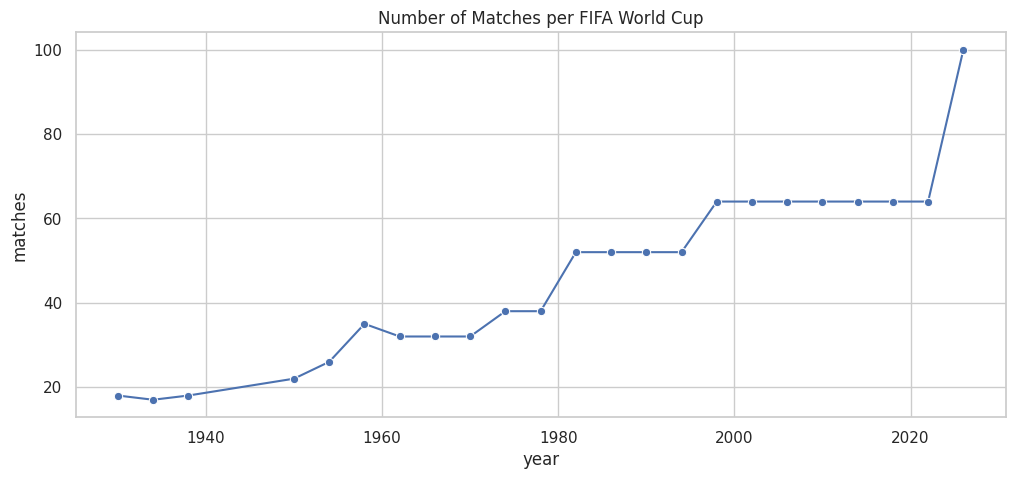

In [24]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=matches_year,
    x='year',
    y='matches',
    marker='o'
)

plt.title("Number of Matches per FIFA World Cup")

plt.savefig(
    "figures/Figure_01_matches_per_cup.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [25]:
#variable of total goals per match
wc_matches['total_goals'] = (
    wc_matches['home_score'] +
    wc_matches['away_score']
)

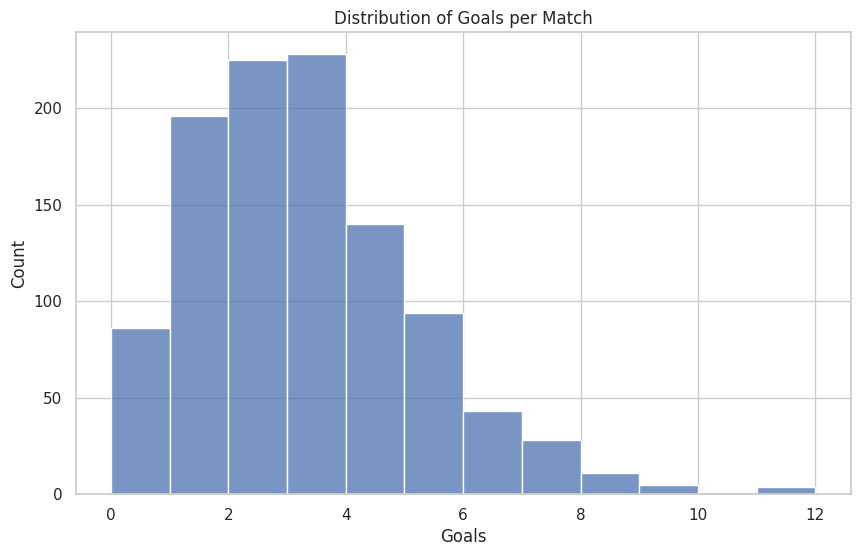

In [26]:
plt.figure(figsize=(10,6))

sns.histplot(
    wc_matches['total_goals'],
    bins=12
)

plt.title("Distribution of Goals per Match")
plt.xlabel("Goals")
plt.savefig(
    "figures/Figure_02_goals_per_match.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [27]:
#countries with more appereances
# Combine home and away teams
all_appearances = pd.concat([
    wc_matches['home_team'],
    wc_matches['away_team']
])

# Count appearances
appearances = (
    all_appearances
    .value_counts()
    .reset_index()
)

appearances.columns = ['country', 'appearances']

# Display the top 20
appearances.head(20)

,country,appearances
0,Brazil,119
1,Germany,116
2,Argentina,94
3,Italy,83
4,England,80
5,France,79
6,Spain,73
7,Mexico,65
8,Uruguay,62
9,Netherlands,59


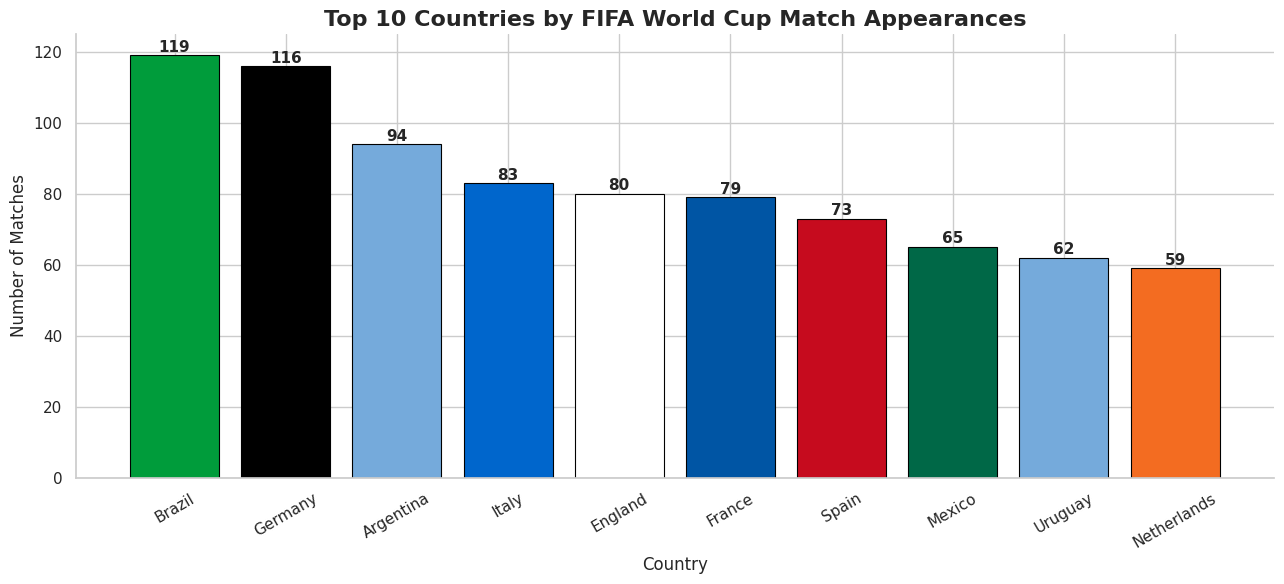

In [28]:
# Top 10 countries by World Cup match appearances
top10 = appearances.head(10).copy()

# Custom colors inspired by national team colors
colors = [
    '#009C3B',  # Brazil - Green
    '#000000',  # Germany - Black
    '#75AADB',  # Argentina - Sky Blue
    '#0066CC',  # Italy - Blue
    '#FFFFFF',  # England - White
    '#0055A4',  # France - Blue
    '#C60B1E',  # Spain - Red
    '#006847',  # Mexico - Green
    '#75AADB',  # Uruguay - Light Blue
    '#F36C21'   # Netherlands - Orange
]

plt.figure(figsize=(13,6))

bars = plt.bar(
    top10['country'],
    top10['appearances'],
    color=colors,
    edgecolor='black',
    linewidth=0.8
)

# Add value labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        int(bar.get_height()),
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.title(
    'Top 10 Countries by FIFA World Cup Match Appearances',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Country', fontsize=12)
plt.ylabel('Number of Matches', fontsize=12)

plt.xticks(rotation=30)

# Clean look
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(
    "figures/Figure_03_top_10_countries_matches.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## <font color='green'>3 Research questions</font> 
### <font color='green'>3.1 Q1 To what extent is GDP per capita associated with a country's FIFA World Cup performance?</font>
First we need to build a subset to evaluate the performance of each team in each game, regardless if it was home or away team.

In [29]:
#Home matches
home = wc_matches[['year',
                   'home_team_std',
                   'home_score',
                   'away_score',
                   'home_gdp_per_capita']].copy()

home.columns = [
    'year',
    'team',
    'goals_for',
    'goals_against',
    'gdp'
]


#Away matches
away = wc_matches[['year',
                   'away_team_std',
                   'away_score',
                   'home_score',
                   'away_gdp_per_capita']].copy()

away.columns = [
    'year',
    'team',
    'goals_for',
    'goals_against',
    'gdp'
]



In [30]:
# Home team result
home['wins'] = (home['goals_for'] > home['goals_against']).astype(int)
home['draws'] = (home['goals_for'] == home['goals_against']).astype(int)
home['losses'] = (home['goals_for'] < home['goals_against']).astype(int)

# Away team result
away['wins'] = (away['goals_for'] > away['goals_against']).astype(int)
away['draws'] = (away['goals_for'] == away['goals_against']).astype(int)
away['losses'] = (away['goals_for'] < away['goals_against']).astype(int)

#assign 3 points on wins, 1 point in draws and 0 in looses
home['points'] = home['wins'] * 3 + home['draws']
away['points'] = away['wins'] * 3 + away['draws']

#join all matches in a single data set
team_matches = pd.concat([home, away], ignore_index=True)

#grouping results by year and team
team_performance = (
    team_matches
    .groupby(['year', 'team'], as_index=False)
    .agg(
        matches=('team', 'size'),
        wins=('wins', 'sum'),
        draws=('draws', 'sum'),
        losses=('losses', 'sum'),
        goals_for=('goals_for', 'sum'),
        goals_against=('goals_against', 'sum'),
        points=('points', 'sum'),
        gdp_per_capita=('gdp', 'first')
    )
)

In [31]:
#Now we will create 4 performance metrics to add in the table that we will use in the next questions
team_performance['goal_difference'] = (
    team_performance['goals_for'] -
    team_performance['goals_against']
)

team_performance['win_percentage'] = (
    team_performance['wins'] /
    team_performance['matches']
).round(3)

team_performance['goals_per_match'] = (
    team_performance['goals_for'] /
    team_performance['matches']
).round(2)

team_performance['goals_conceded_per_match'] = (
    team_performance['goals_against'] /
    team_performance['matches']
).round(2)

team_performance['points_per_match'] = (
    team_performance['points'] /
    team_performance['matches']
).round(2)

In [32]:
print(team_performance.shape)
team_performance.head(100)

(537, 15)


,year,team,matches,wins,draws,losses,goals_for,goals_against,points,gdp_per_capita,goal_difference,win_percentage,goals_per_match,goals_conceded_per_match,points_per_match
0,1930,Argentina,5,4,0,1,18.0,9.0,12,NaN,9.0,0.800,3.60,1.80,2.40
1,1930,Belgium,2,0,0,2,0.0,4.0,0,NaN,-4.0,0.000,0.00,2.00,0.00
2,1930,Bolivia,2,0,0,2,0.0,8.0,0,NaN,-8.0,0.000,0.00,4.00,0.00
3,1930,Brazil,2,1,0,1,5.0,2.0,3,NaN,3.0,0.500,2.50,1.00,1.50
4,1930,Chile,3,2,0,1,5.0,3.0,6,NaN,2.0,0.667,1.67,1.00,2.00
5,1930,France,3,1,0,2,4.0,3.0,3,NaN,1.0,0.333,1.33,1.00,1.00
6,1930,Mexico,3,0,0,3,4.0,13.0,0,NaN,-9.0,0.000,1.33,4.33,0.00
7,1930,Paraguay,2,1,0,1,1.0,3.0,3,NaN,-2.0,0.500,0.50,1.50,1.50
8,1930,Peru,2,0,0,2,1.0,4.0,0,NaN,-3.0,0.000,0.50,2.00,0.00
9,1930,Romania,2,1,0,1,3.0,5.0,3,NaN,-2.0,0.500,1.50,2.50,1.50


In [33]:
# Dataset used for Research Question 1 dropping the rows without gdp data
rq1 = team_performance.dropna(subset=['gdp_per_capita']).copy()

print(f"Observations available for analysis: {len(rq1)}")

Observations available for analysis: 364


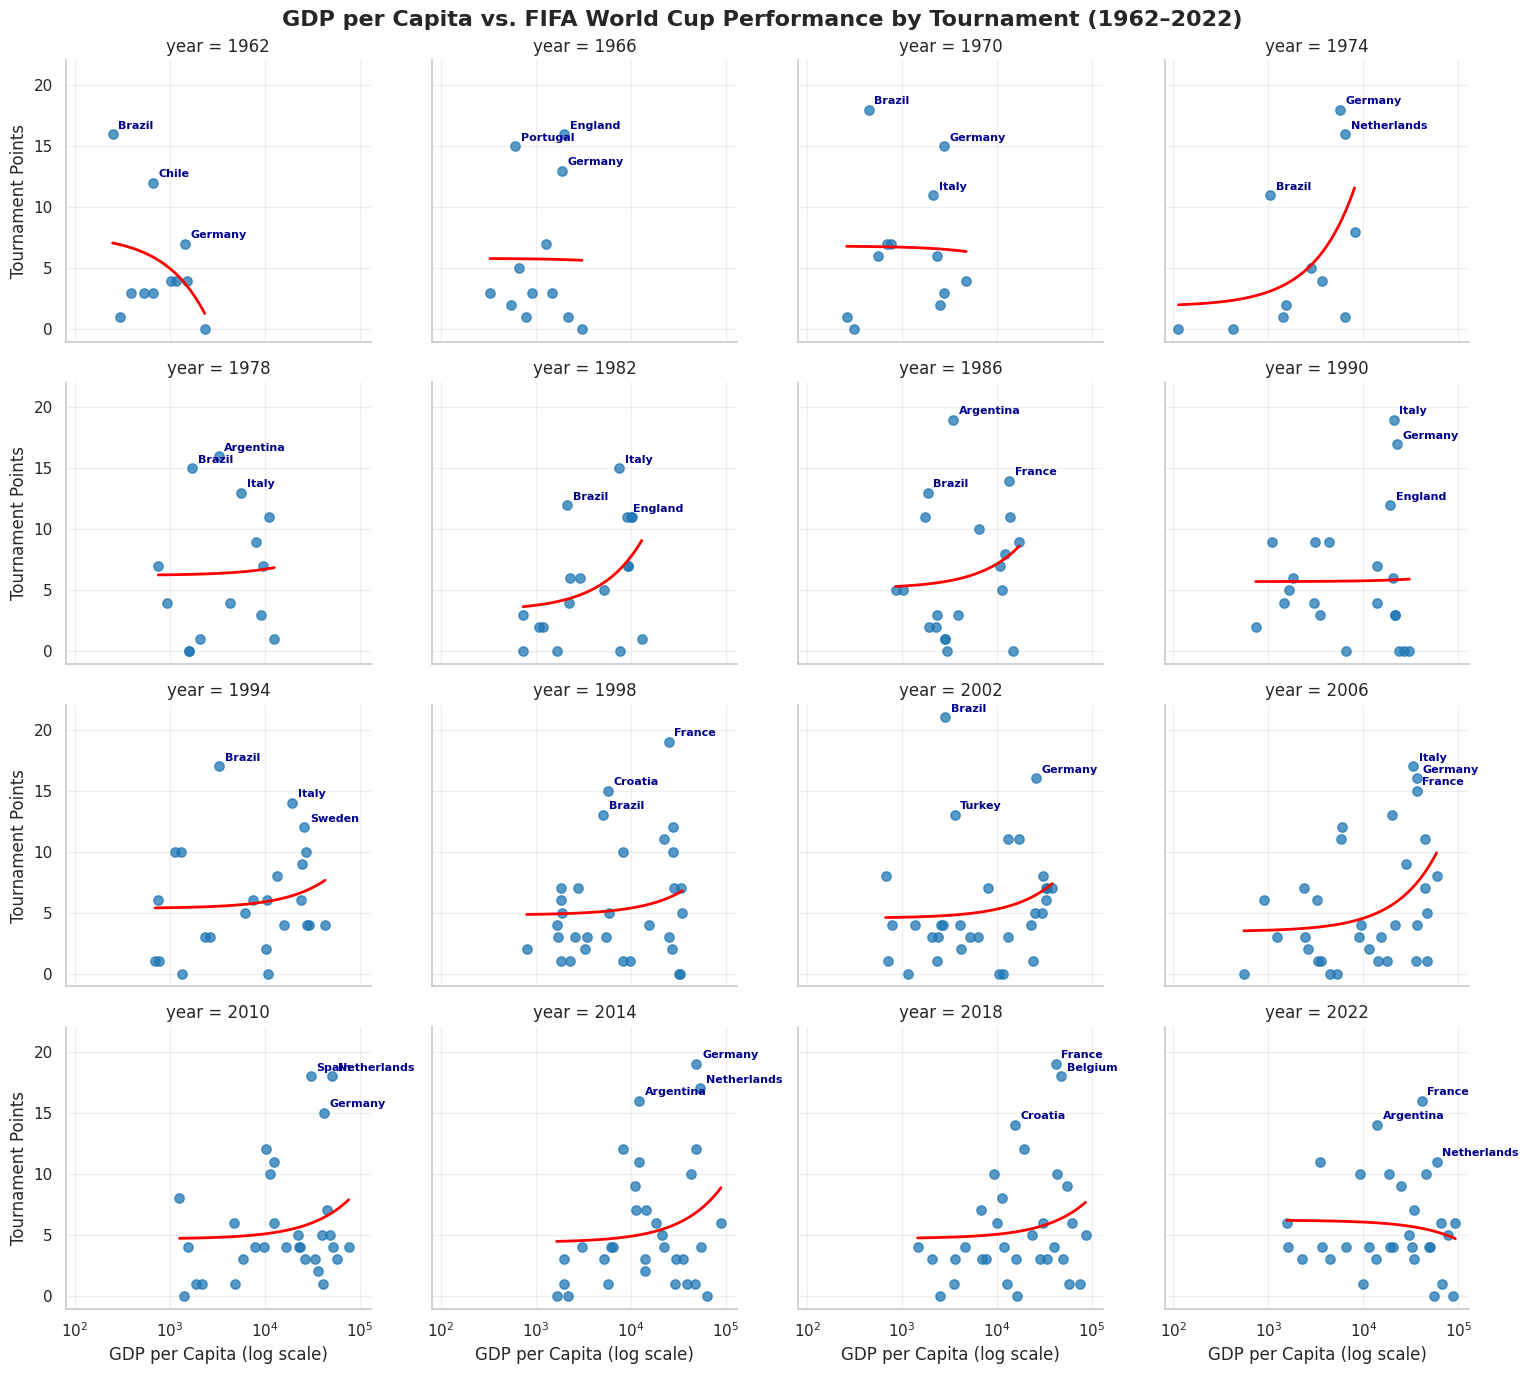

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# Research Question 1 dataset
rq1 = team_performance[
    (team_performance['year'] >= 1962) &
    (team_performance['gdp_per_capita'].notna())
].copy()

g = sns.lmplot(
    data=rq1,
    x='gdp_per_capita',
    y='points',
    col='year',
    col_wrap=4,
    height=3.5,
    aspect=1.1,
    scatter_kws={
        'alpha': 0.75,
        's': 45,
        'color': '#1f77b4'
    },
    line_kws={
        'color': 'red',
        'linewidth': 2
    },
    ci=None
)

# Format each subplot
for year, ax in zip(sorted(rq1['year'].unique()), g.axes.flatten()):

    ax.set_xscale('log')
    ax.grid(alpha=0.3)

    # Top 3 teams by total points
    top3 = (
        rq1[rq1['year'] == year]
        .sort_values(['points', 'goal_difference'], ascending=False)
        .head(3)
    )

    # Add team labels
    for _, row in top3.iterrows():
        ax.annotate(
            row['team'],
            (row['gdp_per_capita'], row['points']),
            xytext=(4,4),
            textcoords='offset points',
            fontsize=8,
            fontweight='bold',
            color='darkblue'
        )

# Axis labels
g.set_axis_labels(
    "GDP per Capita (log scale)",
    "Tournament Points"
)

# Figure title
g.fig.subplots_adjust(top=0.92)
g.fig.suptitle(
    "GDP per Capita vs. FIFA World Cup Performance by Tournament (1962–2022)",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig(
    "figures/Figure_04_gdp_vrs_points.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [35]:
# Create GDP quartiles
rq1['gdp_quartile'] = pd.qcut(
    rq1['gdp_per_capita'],
    q=4,
    labels=[
        'Q1 (Lowest)',
        'Q2',
        'Q3',
        'Q4 (Highest)'
    ]
)

#calculate the avg performance per quartile
quartile_summary = (
    rq1.groupby('gdp_quartile', observed=False)
    .agg(
        Average_Points=('points', 'mean'),
        Average_Wins=('wins', 'mean'),
        Average_Goal_Difference=('goal_difference', 'mean'),
        Average_Goals=('goals_for', 'mean'),
        Teams=('team', 'count')
    )
    .round(2)
)

quartile_summary

,Average_Points,Average_Wins,Average_Goal_Difference,Average_Goals,Teams
gdp_quartile,,,,,
Q1 (Lowest),4.63,1.26,-1.26,4.41,91
Q2,5.40,1.53,-0.08,5.03,91
Q3,6.35,1.73,0.25,5.85,91
Q4 (Highest),6.67,1.87,1.18,6.05,91


/tmp/ipykernel_542124/3744565480.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


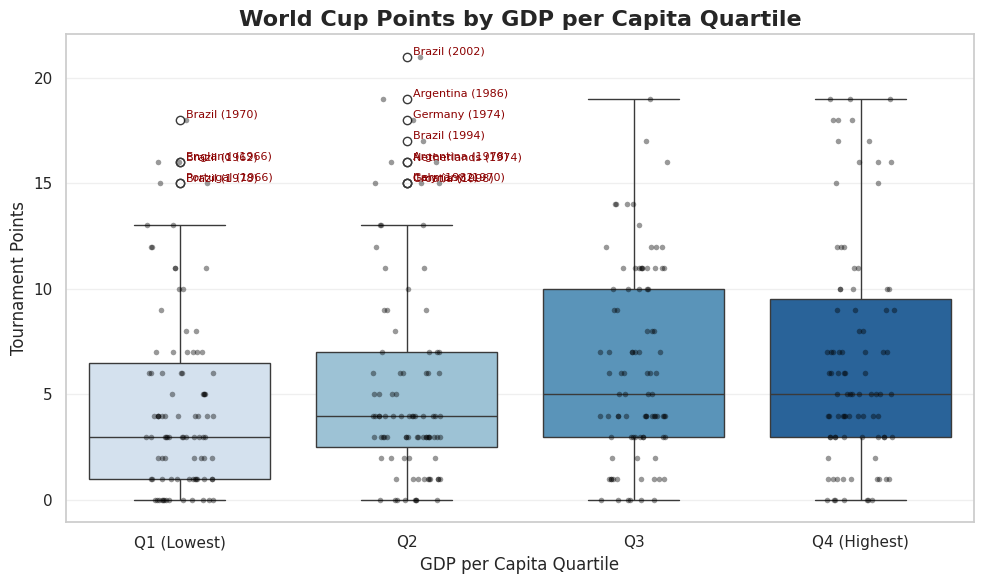

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the plot
plt.figure(figsize=(10,6))

sns.boxplot(
    data=rq1,
    x='gdp_quartile',
    y='points',
    palette='Blues'
)

sns.stripplot(
    data=rq1,
    x='gdp_quartile',
    y='points',
    color='black',
    alpha=0.4,
    size=4,
    jitter=0.15
)

# Identify and label outliers
for quartile in rq1['gdp_quartile'].cat.categories:

    group = rq1[rq1['gdp_quartile'] == quartile]

    q1 = group['points'].quantile(0.25)
    q3 = group['points'].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = group[
        (group['points'] < lower) |
        (group['points'] > upper)
    ]

    # x-position of this quartile
    x = list(rq1['gdp_quartile'].cat.categories).index(quartile)

    for _, row in outliers.iterrows():
        plt.text(
            x + 0.03,
            row['points'] + 0.1,
            f"{row['team']} ({row['year']})",
            fontsize=8,
            color='darkred'
        )

plt.title(
    'World Cup Points by GDP per Capita Quartile',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('GDP per Capita Quartile')
plt.ylabel('Tournament Points')

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

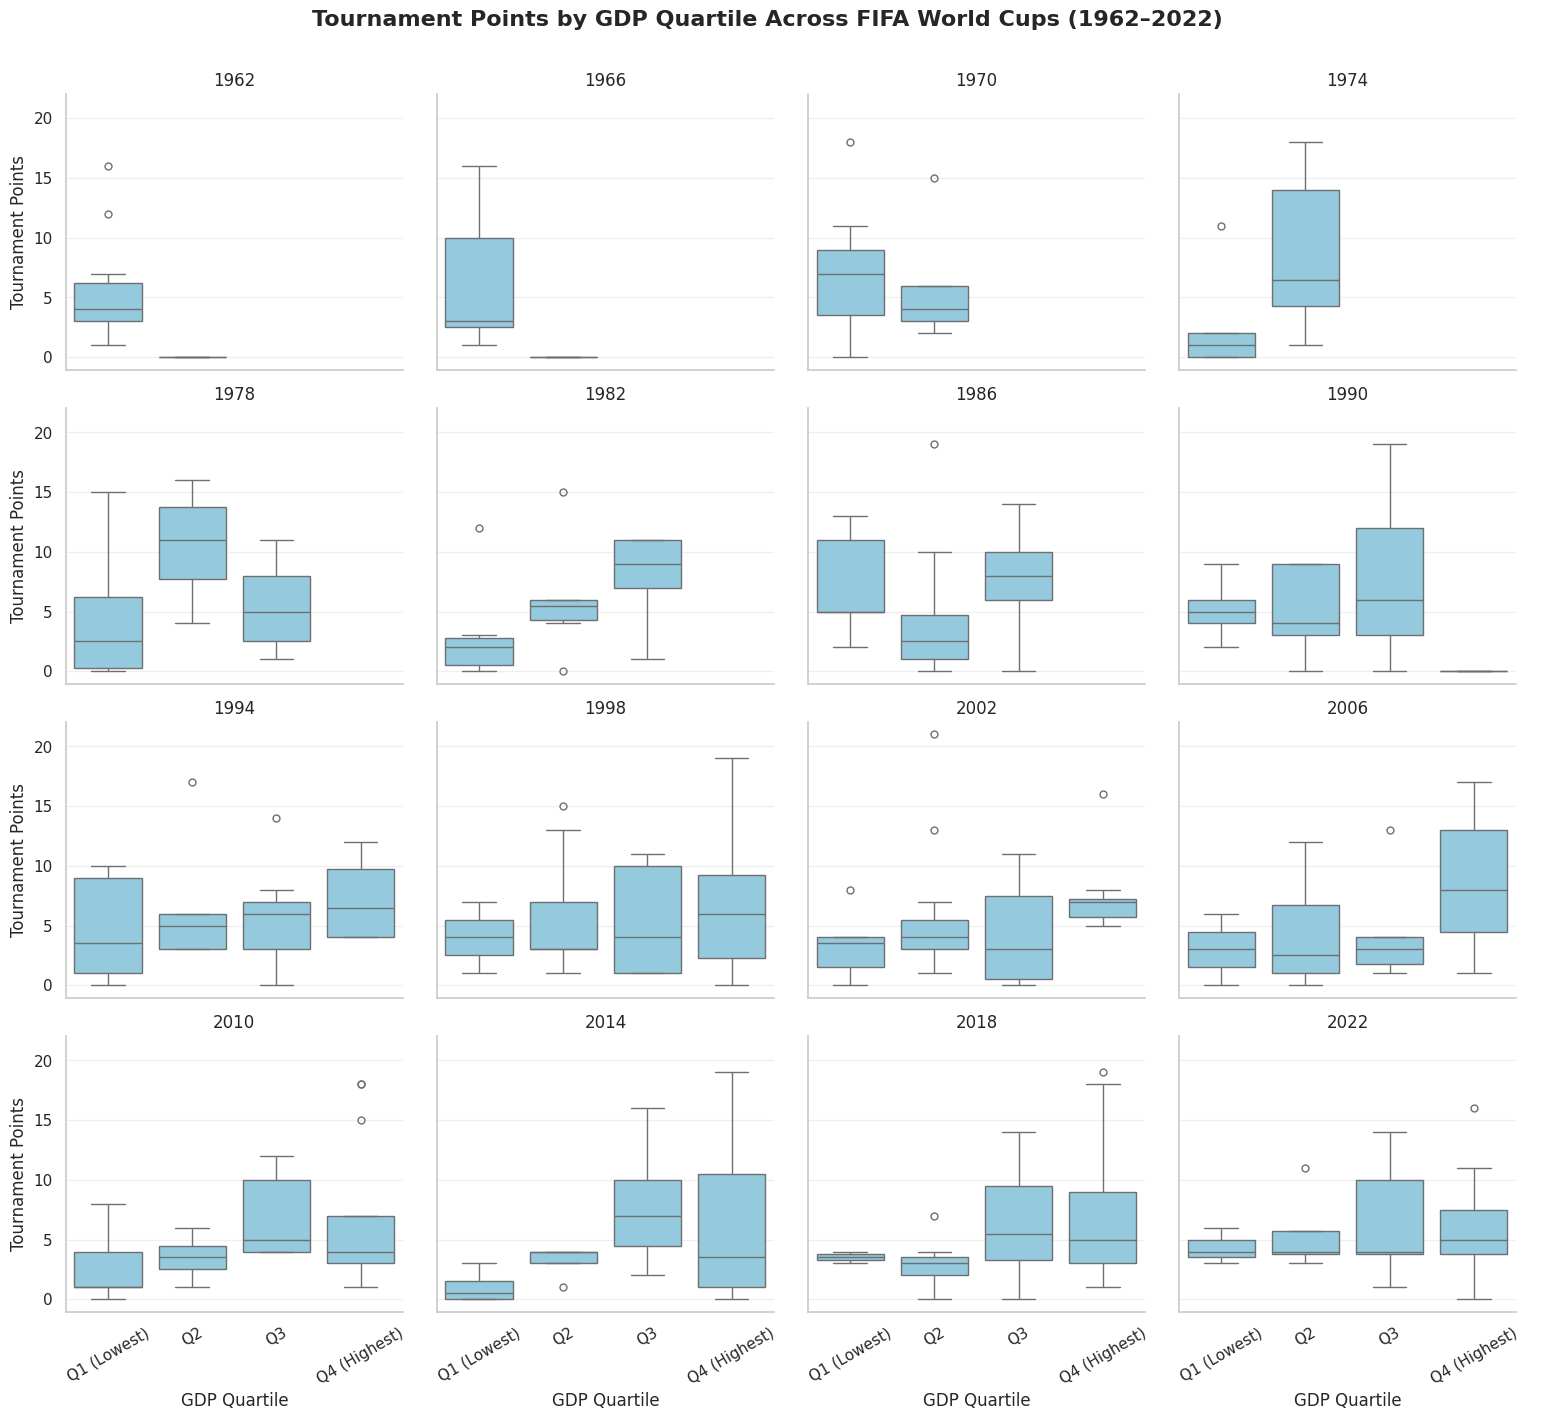

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.catplot(
    data=rq1,
    x='gdp_quartile',
    y='points',
    col='year',
    col_wrap=4,
    kind='box',
    height=3.5,
    aspect=1.1,
    color='skyblue',
    sharey=True
)

g.set_axis_labels("GDP Quartile", "Tournament Points")

g.set_titles("{col_name}")

# Rotate x-axis labels
for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)

g.fig.subplots_adjust(top=0.92)
g.fig.suptitle(
    "Tournament Points by GDP Quartile Across FIFA World Cups (1962–2022)",
    fontsize=16,
    fontweight='bold'
)

plt.show()

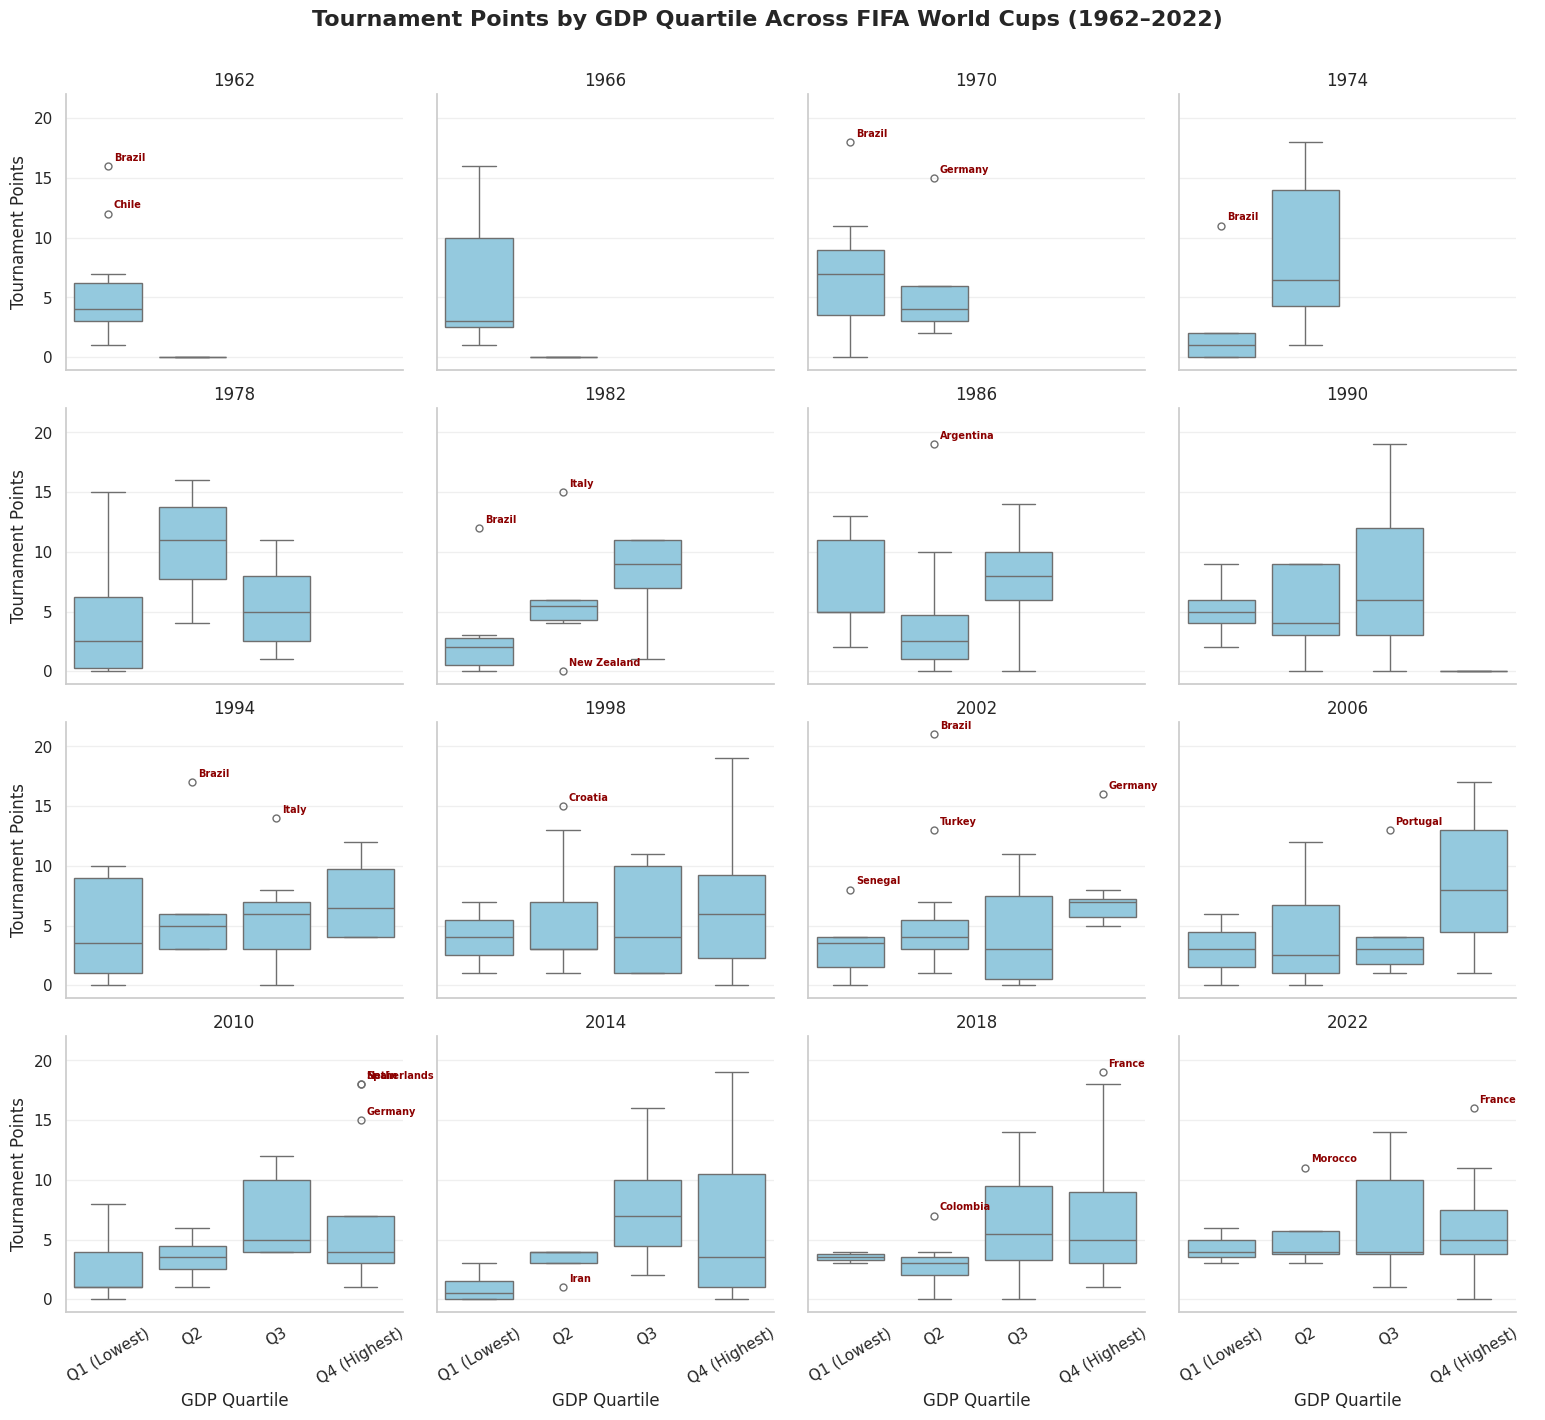

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the faceted boxplots
g = sns.catplot(
    data=rq1,
    x='gdp_quartile',
    y='points',
    col='year',
    col_wrap=4,
    kind='box',
    height=3.5,
    aspect=1.1,
    color='skyblue',
    sharey=True
)

g.set_axis_labels("GDP Quartile", "Tournament Points")
g.set_titles("{col_name}")

quartiles = list(rq1['gdp_quartile'].cat.categories)

# Loop through each subplot (one per World Cup)
for ax, year in zip(g.axes.flatten(), sorted(rq1['year'].unique())):

    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)

    data_year = rq1[rq1['year'] == year]

    # Find outliers within each GDP quartile
    for i, quartile in enumerate(quartiles):

        group = data_year[data_year['gdp_quartile'] == quartile]

        if len(group) < 4:
            continue

        q1 = group['points'].quantile(0.25)
        q3 = group['points'].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outliers = group[
            (group['points'] < lower) |
            (group['points'] > upper)
        ]

        # Label each outlier
        for _, row in outliers.iterrows():

            ax.annotate(
                row['team'],
                xy=(i, row['points']),
                xytext=(4, 4),
                textcoords='offset points',
                fontsize=7,
                color='darkred',
                fontweight='bold'
            )

g.fig.subplots_adjust(top=0.92)

g.fig.suptitle(
    "Tournament Points by GDP Quartile Across FIFA World Cups (1962–2022)",
    fontsize=16,
    fontweight='bold'
)

plt.savefig(
    "figures/Figure_05_GDP_vs_Points_quartile.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### <font color='green'>3.2 Does hosting the FIFA World Cup provide a measurable competitive advantage?
</font> 

In [41]:
# One row per host country and World Cup
hosts = (
    wc_matches[['year', 'country']]
    .drop_duplicates()
    .rename(columns={'country': 'host_country'})
)

hosts.sort_values(['year', 'host_country']).head(26)

,year,host_country
0,1930,Uruguay
18,1934,Italy
35,1938,France
53,1950,Brazil
75,1954,Switzerland
101,1958,Sweden
136,1962,Chile
168,1966,England
200,1970,Mexico
232,1974,Germany


In [42]:
#Adding host indicator
team_host = team_performance.merge(
    hosts,
    left_on=['year', 'team'],
    right_on=['year', 'host_country'],
    how='left'
)

team_host['host'] = team_host['host_country'].notna()

team_host.drop(columns='host_country', inplace=True)

In [43]:
team_host.loc[
    team_host['host'],
    ['year', 'team', 'points_per_match']
].sort_values('year')

,year,team,points_per_match
11,1930,Uruguay,3.00
22,1934,Italy,2.60
33,1938,France,1.50
45,1950,Brazil,2.17
69,1954,Switzerland,1.50
86,1958,Sweden,2.17
92,1962,Chile,2.00
109,1966,England,2.67
130,1970,Mexico,1.75
144,1974,Germany,2.57


In [44]:
host_summary = (
    team_host
    .groupby('team')
    .apply(lambda x: pd.Series({
        'Average_PPM_NonHost': x.loc[~x['host'], 'points_per_match'].mean(),
        'PPM_As_Host': x.loc[x['host'], 'points_per_match'].mean(),
        'Host_Years': x.loc[x['host'], 'year'].astype(str).str.cat(sep=', ')
    }))
    .reset_index()
)

host_summary['Difference'] = (
    host_summary['PPM_As_Host'] -
    host_summary['Average_PPM_NonHost']
)

# Keep only countries that have hosted at least once
host_summary = (
    host_summary[
        host_summary['PPM_As_Host'].notna()
    ]
    .sort_values('Difference', ascending=False)
)

host_summary = host_summary.round(2)

host_summary

/tmp/ipykernel_542124/3150088649.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  team_host


,team,Average_PPM_NonHost,PPM_As_Host,Host_Years,Difference
82,Uruguay,1.26,3.00,1930,1.74
11,Canada,0.00,1.40,2026,1.40
47,Mexico,0.86,2.12,"1970, 1986, 2026",1.26
27,England,1.48,2.67,1966,1.19
41,Italy,1.60,2.66,"1934, 1990",1.06
73,Sweden,1.16,2.17,1958,1.01
13,Chile,1.00,2.00,1962,1.00
71,South Korea,0.64,1.57,2002,0.93
44,Japan,0.92,1.75,2002,0.83
2,Argentina,1.65,2.29,1978,0.64


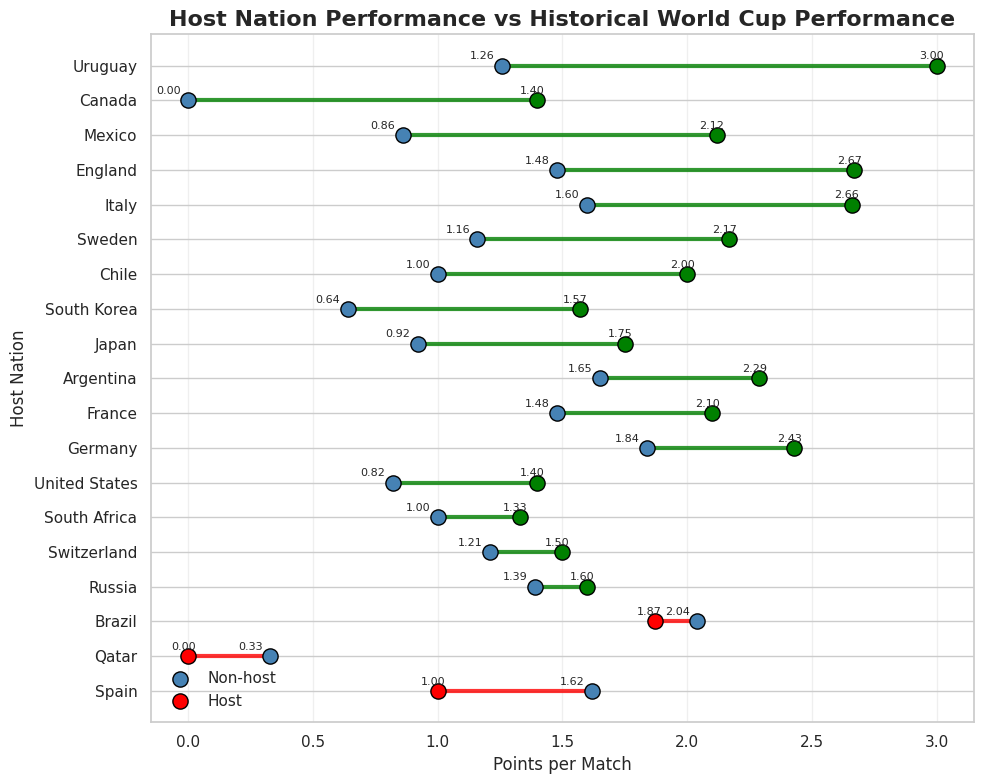

In [47]:
import matplotlib.pyplot as plt
import pandas as pd

# Sort by improvement
plot_df = host_summary.sort_values('Difference').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 8))

for i, row in plot_df.iterrows():

    # Choose color based on improvement
    color = 'green' if row['Difference'] >= 0 else 'red'

    # Connecting line
    ax.plot(
        [row['Average_PPM_NonHost'], row['PPM_As_Host']],
        [i, i],
        color=color,
        linewidth=3,
        alpha=0.8
    )

    # Non-host point
    ax.scatter(
        row['Average_PPM_NonHost'],
        i,
        s=120,
        color='steelblue',
        edgecolor='black',
        zorder=3,
        label='Non-host' if i == 0 else ""
    )

    # Host point
    ax.scatter(
        row['PPM_As_Host'],
        i,
        s=120,
        color=color,
        edgecolor='black',
        zorder=3,
        label='Host' if i == 0 else ""
    )

    # Labels
    ax.text(
        row['Average_PPM_NonHost'] - 0.03,
        i + 0.18,
        f"{row['Average_PPM_NonHost']:.2f}",
        fontsize=8,
        ha='right'
    )

    ax.text(
        row['PPM_As_Host'] + 0.03,
        i + 0.18,
        f"{row['PPM_As_Host']:.2f}",
        fontsize=8,
        ha='right'
    )

ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(plot_df['team'])

ax.set_xlabel("Points per Match")
ax.set_ylabel("Host Nation")

ax.set_title(
    "Host Nation Performance vs Historical World Cup Performance",
    fontsize=16,
    fontweight='bold'
)





ax.grid(axis='x', alpha=0.3)

ax.legend(frameon=False)

plt.tight_layout()

plt.savefig(
    "figures/Figure_06_home_efect.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### <font color='green'>3.3 Which contributes more to World Cup success: attacking efficiency or defensive strength?</font> 

In [48]:
#Lets start with a correlation analysis between the variables of interest
corr = team_performance[
    [
        'points_per_match',
        'goals_per_match',
        'goals_conceded_per_match',
        'goal_difference'
    ]
].corr()

corr

,points_per_match,goals_per_match,goals_conceded_per_match,goal_difference
points_per_match,1.000000,0.619558,-0.599492,0.853878
goals_per_match,0.619558,1.000000,-0.074094,0.700008
goals_conceded_per_match,-0.599492,-0.074094,1.000000,-0.654952
goal_difference,0.853878,0.700008,-0.654952,1.000000


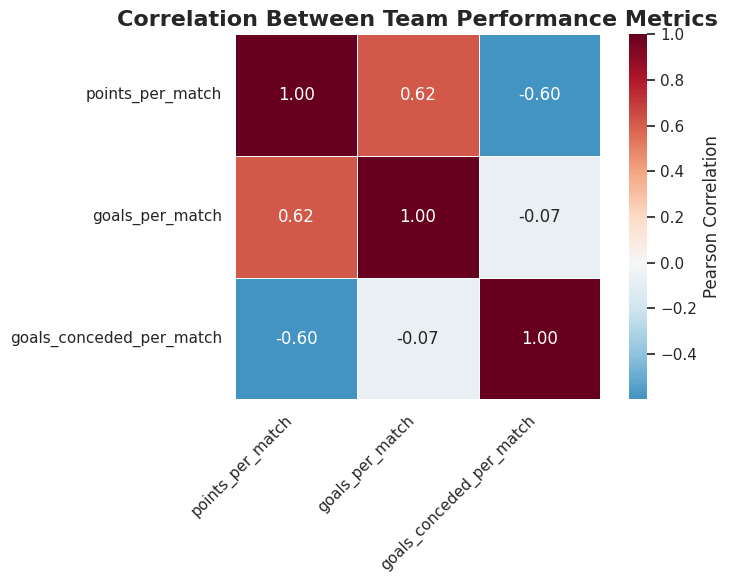

In [50]:
# Variables of interest
corr_vars = [
    'points_per_match',
    'goals_per_match',
    'goals_conceded_per_match',
    
]

# Compute correlation matrix
corr = team_performance[corr_vars].corr()

# Plot
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Pearson Correlation'}
)

plt.title(
    "Correlation Between Team Performance Metrics",
    fontsize=16,
    fontweight='bold'
)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "figures/Figure_07_correlation_goals.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

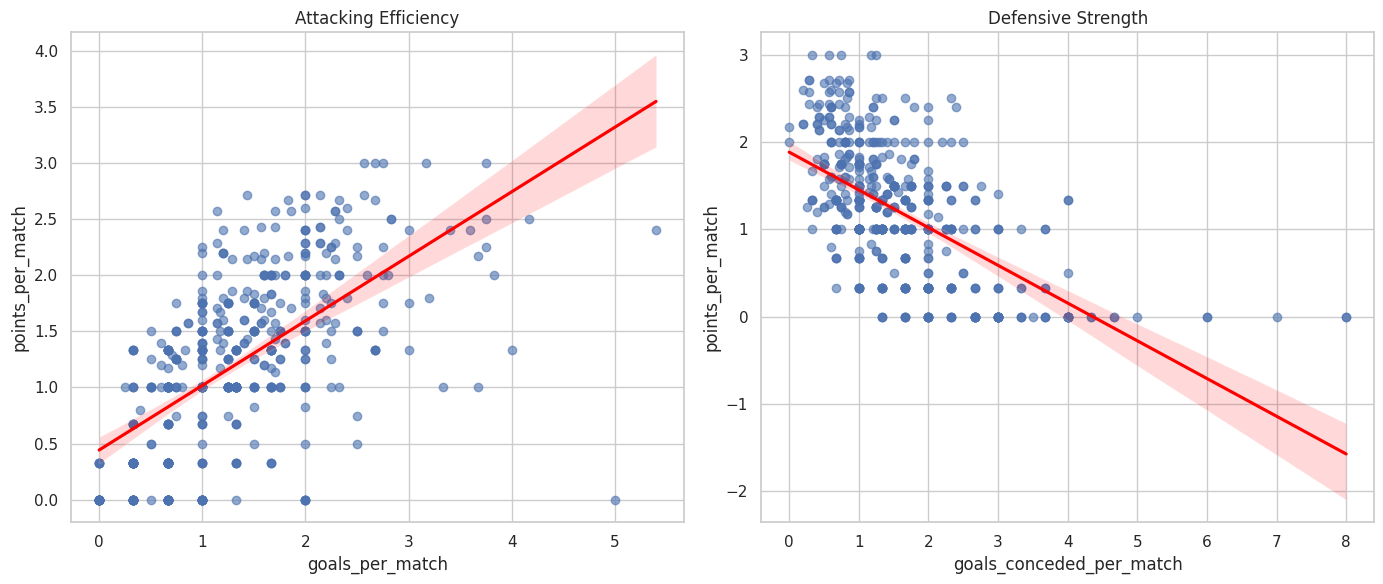

In [52]:
fig, ax = plt.subplots(1,2, figsize=(14,6))

sns.regplot(
    data=team_performance,
    x='goals_per_match',
    y='points_per_match',
    ax=ax[0],
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)

ax[0].set_title("Attacking Efficiency")

sns.regplot(
    data=team_performance,
    x='goals_conceded_per_match',
    y='points_per_match',
    ax=ax[1],
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)

ax[1].set_title("Defensive Strength")

plt.tight_layout()
plt.savefig(
    "figures/Figure_08_correlation_goals_trend.png",
    dpi=300,
    bbox_inches="tight"
)

Some aditional context graphs that might add value in the final report.
First one that shows the average goals per game in each cup alonside the team that score more goals in each cup.

In [53]:
#Calculate the average goals per game for each World Cup
worldcup_goals = (
    wc_matches
    .groupby('year')
    .agg(
        total_goals=('home_score', lambda x: x.sum()),
        total_home=('home_score', 'sum'),
        total_away=('away_score', 'sum'),
        matches=('home_score', 'count')
    )
    .reset_index()
)

worldcup_goals['total_goals'] = (
    worldcup_goals['total_home'] +
    worldcup_goals['total_away']
)

worldcup_goals['avg_goals_per_game'] = (
    worldcup_goals['total_goals'] /
    worldcup_goals['matches']
)

#Find the highest scoring team in each World Cup
home_goals = (
    wc_matches.groupby(['year','home_team'])['home_score']
    .sum()
    .reset_index()
    .rename(columns={
        'home_team':'team',
        'home_score':'goals'
    })
)

away_goals = (
    wc_matches.groupby(['year','away_team'])['away_score']
    .sum()
    .reset_index()
    .rename(columns={
        'away_team':'team',
        'away_score':'goals'
    })
)

team_goals = (
    pd.concat([home_goals, away_goals])
      .groupby(['year','team'])['goals']
      .sum()
      .reset_index()
)

top_scorers = (
    team_goals
    .sort_values(['year','goals'], ascending=[True,False])
    .drop_duplicates('year')
)

top_scorers.rename(
    columns={
        'team':'top_team',
        'goals':'top_goals'
    },
    inplace=True
)

#Merge both
worldcup_goals = worldcup_goals.merge(
    top_scorers,
    on='year',
    how='left'
)



In [54]:
champions = {
    1930: "Uruguay",
    1934: "Italy",
    1938: "Italy",
    1950: "Uruguay",
    1954: "Germany",
    1958: "Brazil",
    1962: "Brazil",
    1966: "England",
    1970: "Brazil",
    1974: "Germany",
    1978: "Argentina",
    1982: "Italy",
    1986: "Argentina",
    1990: "Germany",
    1994: "Brazil",
    1998: "France",
    2002: "Brazil",
    2006: "Italy",
    2010: "Spain",
    2014: "Germany",
    2018: "France",
    2022: "Argentina"
}

worldcup_goals["champion"] = worldcup_goals["year"].map(champions)

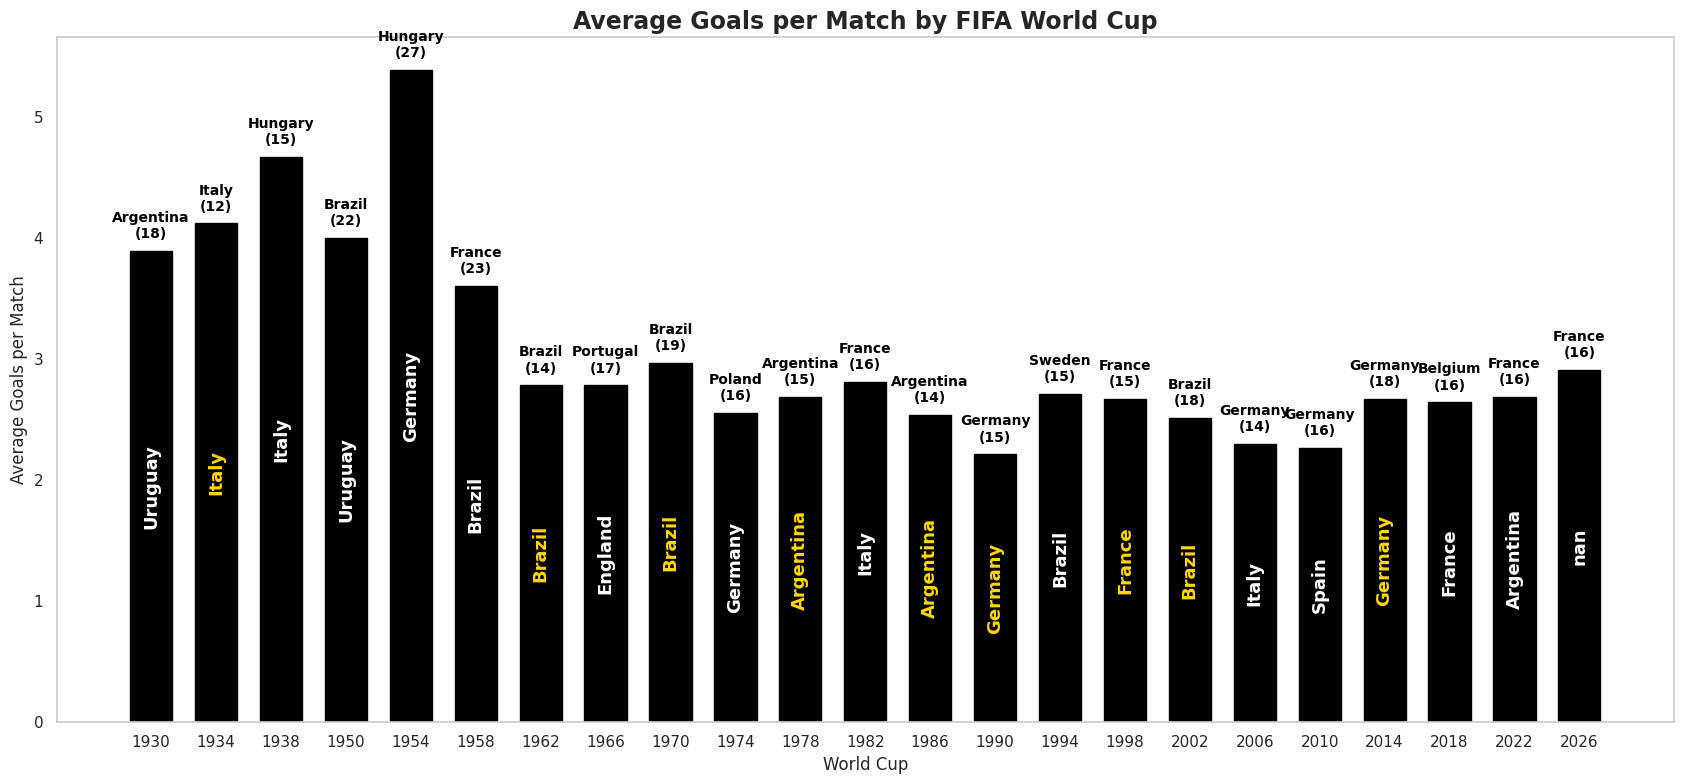

In [56]:
import matplotlib.pyplot as plt

plot_df = worldcup_goals.sort_values("year")

plt.figure(figsize=(17,8))

bars = plt.bar(
    plot_df["year"].astype(str),
    plot_df["avg_goals_per_game"],
    color="black",
    edgecolor="black",
    width=0.65
)

for bar, (_, row) in zip(bars, plot_df.iterrows()):

    x = bar.get_x() + bar.get_width()/2
    y = bar.get_height()

    # Top scoring team
    plt.text(
        x,
        y + 0.08,
        f"{row['top_team']}\n({int(row['top_goals'])})",
        ha="center",
        va="bottom",
        fontsize=10,
        color="black",
        fontweight="bold"
    )

    # Champion inside the bar (vertical)
    champion_color = (
        "gold"
        if row["champion"] == row["top_team"]
        else "white"
    )

    plt.text(
        x,
        y/2,
        row["champion"],
        ha="center",
        va="center",
        rotation=90,
        fontsize=13,
        color=champion_color,
        fontweight="bold"
    )

plt.title(
    "Average Goals per Match by FIFA World Cup",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("World Cup")
plt.ylabel("Average Goals per Match")

plt.grid(False)

plt.tight_layout()




plt.savefig(
    "figures/Figure_01_GDP_vs_Points.png",
    dpi=300,
    bbox_inches="tight"
)


plt.savefig(
    "figures/Figure_09_avg_goals_champion.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [57]:
# Export to CSV to use in the dashboard
team_performance.to_csv(
    "team_performance.csv",
    index=False,
    encoding="utf-8-sig"
)